[![Abrir no Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lalvim/DataMining/blob/main/notebooks/unidade_05/05_01_processo_e_avaliacao_de_classificacao.ipynb)

# Unidade V — Classificação e Regressão

## Processo e avaliação de classificação

**Carga estimada:** 3 horas  
**Pré-requisitos:** estatística descritiva, preparação de dados e Python com pandas.

> **Pergunta norteadora:** como transformar dados históricos rotulados em uma previsão útil, sem confundir bom desempenho aparente com capacidade de generalizar para novos casos?

Neste notebook, o foco não é dominar toda a teoria de aprendizado de máquina. O objetivo é compreender o processo de mineração supervisionada, interpretar seus resultados e reconhecer decisões que podem tornar uma análise enganosa.

## Objetivos de aprendizagem

Ao concluir este notebook, você será capaz de:

- distinguir classificação de regressão pela natureza da variável-alvo;
- identificar atributos, alvo, exemplos rotulados e previsões;
- explicar as funções dos conjuntos de treino e teste;
- comparar um classificador com uma referência simples (*baseline*);
- ler uma matriz de confusão e interpretar acurácia, precisão, revocação e F1;
- relacionar limiar de decisão, desbalanceamento e custo dos erros;
- reconhecer vazamento de dados e evitar conclusões causais indevidas.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

RANDOM_STATE = 42

## 1. Antes do algoritmo: qual é a pergunta?

Em mineração de dados supervisionada, há exemplos históricos com uma resposta conhecida, chamada **variável-alvo**. O método procura regularidades entre os atributos e esse alvo para estimar a resposta de novos casos.

| Tarefa | Tipo de alvo | Pergunta típica | Exemplo de saída |
|---|---|---|---|
| Classificação | categoria | “Este cliente tende a cancelar?” | `sim` ou `não` |
| Regressão | número | “Qual será o consumo mensal?” | 184,7 kWh |

Usar números como códigos de classe não transforma classificação em regressão. Se `0`, `1` e `2` apenas representam categorias sem distância numérica significativa, o problema continua sendo de classificação.

O capítulo 6 de Han, Pei e Tong apresenta classificação como um processo em duas etapas: aprender um modelo com exemplos rotulados e avaliar se ele é adequado antes de aplicá-lo a novos objetos. A regressão aparece como uma tarefa supervisionada próxima, mas com alvo numérico.

## 2. O fluxo supervisionado sob o olhar da mineração de dados

O fluxo pode ser resumido assim:

$$
\text{problema}
\rightarrow
\text{dados históricos}
\rightarrow
\text{treino/teste}
\rightarrow
\text{modelo}
\rightarrow
\text{avaliação}
\rightarrow
\text{uso monitorado}.
$$

Cada etapa responde a uma pergunta:

1. **Problema:** qual decisão será apoiada e qual é a unidade de análise?
2. **Dados históricos:** quais atributos estariam disponíveis no momento da previsão?
3. **Treino:** quais padrões o método consegue encontrar nos exemplos conhecidos?
4. **Teste:** o padrão funciona em casos que não participaram do aprendizado?
5. **Avaliação:** quais erros são aceitáveis no contexto?
6. **Uso monitorado:** o desempenho permanece válido quando população e comportamento mudam?

O modelo é apenas uma etapa do processo. Uma métrica alta não corrige um alvo mal definido, dados enviesados ou atributos que revelam indevidamente o futuro.

## 3. Estudo de caso: priorização de clientes para retenção

Considere uma empresa que deseja investigar clientes com maior risco de cancelamento. Cada linha representa um cliente em uma data de referência. O alvo `cancelou` informa se houve cancelamento no período seguinte.

Os dados abaixo são **sintéticos e autorais**. Foram construídos apenas para tornar o processo reproduzível; não representam uma população real.

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n_clientes = 600

clientes = pd.DataFrame({
    "tempo_como_cliente": rng.integers(1, 73, n_clientes),
    "valor_mensal": np.clip(rng.normal(110, 30, n_clientes), 30, 220).round(2),
    "chamados_suporte": rng.poisson(1.3, n_clientes),
    "atrasos_pagamento": rng.binomial(3, 0.18, n_clientes),
    "contrato_mensal": rng.binomial(1, 0.45, n_clientes),
})

escore = (
    -2.7
    - 0.025 * clientes["tempo_como_cliente"]
    + 0.006 * (clientes["valor_mensal"] - 100)
    + 0.55 * clientes["chamados_suporte"]
    + 0.80 * clientes["atrasos_pagamento"]
    + 0.75 * clientes["contrato_mensal"]
)
probabilidade_cancelamento = 1 / (1 + np.exp(-escore))
clientes["cancelou"] = rng.binomial(1, probabilidade_cancelamento)

display(clientes.head())
display(
    clientes["cancelou"]
    .value_counts()
    .rename(index={0: "não cancelou", 1: "cancelou"})
    .to_frame("quantidade")
    .assign(proporcao=lambda tabela: tabela["quantidade"] / len(clientes))
)

,tempo_como_cliente,valor_mensal,chamados_suporte,atrasos_pagamento,contrato_mensal,cancelou
0,7,101.23,0,1,1,0
1,56,106.90,3,3,1,0
2,48,102.44,0,0,0,0
3,32,114.58,0,0,0,1
4,32,154.14,3,0,1,1


,quantidade,proporcao
cancelou,,
não cancelou,503,0.838333
cancelou,97,0.161667


### O que o conjunto representa — e o que não representa

- **Unidade de análise:** um cliente na data de referência.
- **Atributos:** informações disponíveis até essa data.
- **Alvo:** cancelamento observado posteriormente.
- **Classe positiva:** `cancelou = 1`, pois é o evento de interesse.

A relação temporal importa. Um atributo como `motivo_do_cancelamento`, registrado somente depois do evento, entregaria a resposta ao modelo. Isso seria **vazamento de dados** (*data leakage*): a avaliação pareceria excelente, mas a informação não estaria disponível quando a previsão fosse necessária.

O alvo também não prova causalidade. Se clientes com mais chamados apresentarem maior risco, não se conclui automaticamente que os chamados causam cancelamento; eles podem refletir problemas anteriores no serviço.

## 4. Treino e teste: aprender em um conjunto, verificar em outro

Usar os mesmos exemplos para aprender e avaliar favorece uma estimativa otimista. O método pode memorizar particularidades que não se repetem.

Neste exemplo:

- **treino:** 75% dos clientes, usados para ajustar o modelo;
- **teste:** 25%, mantidos fora do treinamento;
- **estratificação:** preserva aproximadamente a proporção das classes nos dois conjuntos;
- **semente fixa:** torna a divisão reproduzível.

Em projetos reais, a separação deve respeitar o modo de uso. Quando se prevê o futuro, uma divisão temporal costuma ser mais realista que uma divisão aleatória.

In [3]:
atributos = [
    "tempo_como_cliente",
    "valor_mensal",
    "chamados_suporte",
    "atrasos_pagamento",
    "contrato_mensal",
]
X = clientes[atributos]
y = clientes["cancelou"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

resumo_particoes = pd.DataFrame({
    "particao": ["treino", "teste"],
    "n": [len(y_treino), len(y_teste)],
    "proporcao_cancelamento": [y_treino.mean(), y_teste.mean()],
})
resumo_particoes.round(3)

,particao,n,proporcao_cancelamento
0,treino,450,0.162
1,teste,150,0.160


## 5. Um modelo deve superar uma referência simples

Antes de valorizar um algoritmo, precisamos perguntar: **o que aconteceria com uma estratégia trivial?**

O `DummyClassifier` abaixo sempre prevê a classe mais frequente. Ele não descobre relações entre os atributos; funciona como um piso de comparação. O segundo modelo é uma árvore de decisão pequena, usada aqui apenas para percorrer o processo. Sua intuição será estudada no notebook 05.03.

Se 90% dos casos fossem negativos, prever sempre “não” produziria 90% de acurácia e ainda assim deixaria de encontrar todos os positivos. Por isso, acurácia isolada pode ser enganosa.

In [4]:
baseline = DummyClassifier(strategy="most_frequent")
arvore = DecisionTreeClassifier(
    max_depth=4,
    min_samples_leaf=20,
    random_state=RANDOM_STATE,
)

baseline.fit(X_treino, y_treino)
arvore.fit(X_treino, y_treino)

def calcular_metricas(nome, modelo):
    previsoes = modelo.predict(X_teste)
    probabilidades = modelo.predict_proba(X_teste)[:, 1]
    return {
        "modelo": nome,
        "acuracia": accuracy_score(y_teste, previsoes),
        "precisao": precision_score(y_teste, previsoes, zero_division=0),
        "revocacao": recall_score(y_teste, previsoes, zero_division=0),
        "f1": f1_score(y_teste, previsoes, zero_division=0),
        "auc_roc": roc_auc_score(y_teste, probabilidades),
    }

comparacao = pd.DataFrame([
    calcular_metricas("baseline: classe majoritária", baseline),
    calcular_metricas("árvore rasa", arvore),
])
comparacao.round(3)

,modelo,acuracia,precisao,revocacao,f1,auc_roc
0,baseline: classe majoritária,0.840,0.000,0.000,0.000,0.500
1,árvore rasa,0.833,0.455,0.208,0.286,0.716


## 6. Matriz de confusão: dar nome aos acertos e erros

Para uma classe positiva de interesse, cada previsão ocupa uma das quatro posições:

|  | Previsto negativo | Previsto positivo |
|---|---:|---:|
| **Real negativo** | verdadeiro negativo (VN) | falso positivo (FP) |
| **Real positivo** | falso negativo (FN) | verdadeiro positivo (VP) |

A partir delas:

$$
\operatorname{Acurácia}=\frac{VP+VN}{VP+VN+FP+FN},
$$

$$
\operatorname{Precisão}=\frac{VP}{VP+FP},
\qquad
\operatorname{Revocação}=\frac{VP}{VP+FN},
$$

$$
F1=2\frac{\operatorname{Precisão}\times\operatorname{Revocação}}
{\operatorname{Precisão}+\operatorname{Revocação}}.
$$

- **Precisão:** entre os clientes sinalizados, quantos realmente cancelaram?
- **Revocação:** entre os que realmente cancelaram, quantos foram encontrados?
- **F1:** resumo harmônico de precisão e revocação; não incorpora diretamente custos financeiros.
- **Acurácia:** proporção total de acertos; precisa ser comparada à distribuição das classes e ao *baseline*.

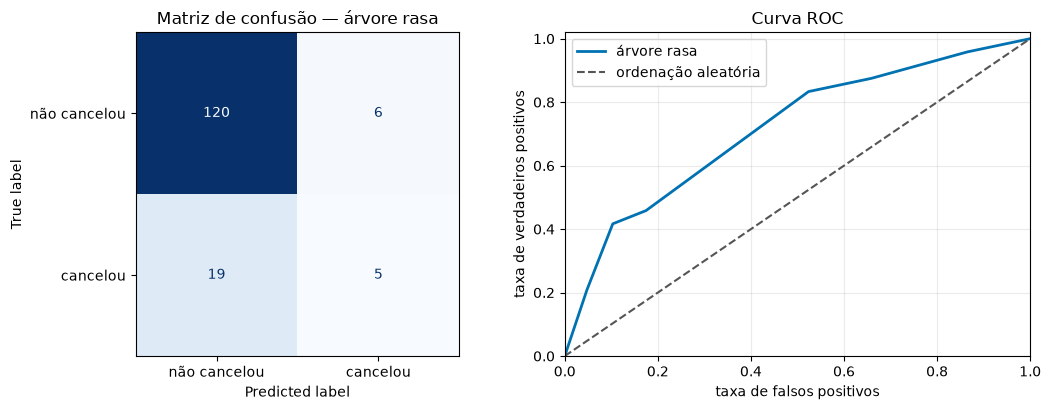

,VN,FP,FN,VP
0,120,6,19,5


In [5]:
previsoes_arvore = arvore.predict(X_teste)
probabilidades_arvore = arvore.predict_proba(X_teste)[:, 1]
matriz = confusion_matrix(y_teste, previsoes_arvore)
fpr, tpr, _ = roc_curve(y_teste, probabilidades_arvore)

fig, eixos = plt.subplots(1, 2, figsize=(11, 4.2))

ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["não cancelou", "cancelou"],
).plot(ax=eixos[0], cmap="Blues", colorbar=False)
eixos[0].set_title("Matriz de confusão — árvore rasa")

eixos[1].plot(fpr, tpr, color="#0072B2", linewidth=2, label="árvore rasa")
eixos[1].plot([0, 1], [0, 1], "--", color="#555555", label="ordenação aleatória")
eixos[1].set(
    title="Curva ROC",
    xlabel="taxa de falsos positivos",
    ylabel="taxa de verdadeiros positivos",
    xlim=(0, 1),
    ylim=(0, 1.02),
)
eixos[1].legend()
eixos[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

vn, fp, fn, vp = matriz.ravel()
pd.DataFrame({"VN": [vn], "FP": [fp], "FN": [fn], "VP": [vp]})

### Como interpretar os resultados

A matriz revela erros que uma única média esconderia. No cenário de retenção:

- um **falso positivo** direciona contato a alguém que não cancelaria;
- um **falso negativo** deixa de sinalizar alguém que cancelará.

A gravidade depende da ação. Uma mensagem de baixo custo pode tolerar mais falsos positivos; uma oferta cara exige maior precisão.

A curva ROC mostra como a taxa de verdadeiros positivos e a taxa de falsos positivos mudam com diferentes limiares. A **área sob a curva ROC (AUC-ROC)** pode ser interpretada, intuitivamente, como capacidade de ordenar um positivo acima de um negativo. Valor 0,5 corresponde a uma ordenação sem vantagem; valor 1 indica ordenação perfeita no conjunto avaliado. A AUC não escolhe o limiar nem substitui a análise de custos.

## 7. O limiar transforma escores em decisões

O modelo produz um escore entre 0 e 1. O limiar padrão 0,5 não é uma lei: reduzi-lo tende a encontrar mais positivos, mas também aumenta falsos alarmes.

A tabela seguinte compara limiares e inclui um custo didático:

$$
\text{custo}=1\times FP+5\times FN.
$$

Nesse cenário hipotético, deixar de detectar um cancelamento custa cinco vezes mais que contatar um cliente que não cancelaria. Os pesos são uma decisão do problema, não uma propriedade do algoritmo.

In [6]:
linhas_limiares = []
for limiar in [0.30, 0.50, 0.70]:
    previsoes = (probabilidades_arvore >= limiar).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_teste, previsoes).ravel()
    linhas_limiares.append({
        "limiar": limiar,
        "VP": vp,
        "FP": fp,
        "FN": fn,
        "VN": vn,
        "precisao": precision_score(y_teste, previsoes, zero_division=0),
        "revocacao": recall_score(y_teste, previsoes, zero_division=0),
        "custo_hipotetico": fp + 5 * fn,
    })

tabela_limiares = pd.DataFrame(linhas_limiares)
tabela_limiares.round(3)

,limiar,VP,FP,FN,VN,precisao,revocacao,custo_hipotetico
0,0.3,10,13,14,113,0.435,0.417,83
1,0.5,5,6,19,120,0.455,0.208,101
2,0.7,0,0,24,126,0.000,0.000,120


### Não existe “melhor limiar” sem contexto

O limiar com menor custo na tabela é preferível **apenas sob os pesos declarados**. Se o contato fosse invasivo, limitado ou caro, o peso do falso positivo deveria aumentar. Além disso, probabilidades mal calibradas, mudança da população e capacidade operacional podem alterar a escolha.

Essa é a perspectiva de mineração de dados adotada na unidade: o método encontra padrões, mas a decisão exige relacionar dados, métrica, erro e uso real.

## Atividades

> **U05-NB01-V01 — Verifique seu entendimento:** em uma base com 10% de positivos, um classificador que sempre prevê a classe negativa obtém 90% de acurácia. Por que isso não demonstra utilidade para encontrar positivos? Indique os valores esperados de revocação e F1 para a classe positiva.

> **U05-NB01-E01 — Exercício:** usando a matriz de confusão exibida para a árvore, recalcule acurácia, precisão, revocação e F1. Depois, interprete FP e FN no cenário de retenção. Apresente fórmulas, substituição numérica e arredondamento a três casas.

> **U05-NB01-E02 — Exercício de decisão:** na tabela de limiares, identifique o menor custo hipotético para $\text{custo}=FP+5FN$. Explique por que essa escolha pode mudar se o contato com um cliente for caro ou invasivo.

## Síntese

- Classificação prevê categorias; regressão prevê valores numéricos.
- Treino serve para aprender e teste serve para estimar generalização.
- Um *baseline* impede que desempenho trivial pareça uma descoberta relevante.
- Matriz de confusão, precisão, revocação e F1 mostram diferentes aspectos do erro.
- Desbalanceamento e custos tornam a acurácia insuficiente em muitos problemas.
- O limiar deve refletir o uso pretendido e pode mudar após implantação.
- Desempenho preditivo descreve previsão; não demonstra causalidade.

## Referências

- HAN, Jiawei; PEI, Jian; TONG, Hanghang. *Data Mining: Concepts and Techniques*. 4. ed. Cambridge: Morgan Kaufmann/Elsevier, 2023. Cap. 6, seções 6.1 e 6.6.
- SCIKIT-LEARN DEVELOPERS. *User Guide: Model evaluation*. Documentação da biblioteca utilizada nos exemplos computacionais.